[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/danpele/Time-Series-Analysis/blob/main/notebooks/EN/chapter0_lecture_notebook.ipynb)

# Time Series Analysis — Chapter 0: Introduction, Components and Exponential Smoothing

*Lecture notebook. Daniel Traian Pele, Bucharest University of Economic Studies.*

- Reproduces every chart and number of the Chapter 0 lecture.
- Data: Eurostat (Romanian GDP, HICP, electricity generation), the BNR reference rate (EUR/RON), daily market data from EODHD (BET, S&P 500), the CO2 data set of statsmodels.
- Sections: six series on real data; Slutsky's experiment; decomposition (classical and STL); transformations and the ACF; simple exponential smoothing; forecasts and their evaluation.

> **Working in Google Colab? Save your own copy first.**
> The Colab link opens a temporary copy: when you close the tab or the session times out, your changes are lost.
> Use **File → Save a copy in Drive** (it goes to the *Colab Notebooks* folder of your ASE Google Drive) and work in that copy.
> For the team project, **File → Save a copy in GitHub** puts the notebook directly in your team's repository.
> Files you create while the notebook runs (CSV, charts) are also temporary: set `SAVE_TO_DRIVE = True` in the next cell to keep them.

In [1]:
# Optional (Colab only): keep the files you create in Google Drive
SAVE_TO_DRIVE = False   # set to True, run this cell and allow access to your Drive

import os
OUT_DIR = '.'
if SAVE_TO_DRIVE:
    from google.colab import drive
    drive.mount('/content/drive')
    OUT_DIR = '/content/drive/MyDrive/TSA/Chapter_0'
    os.makedirs(OUT_DIR, exist_ok=True)
print('Save your outputs to:', os.path.abspath(OUT_DIR))


Save your outputs to: /Users/danpele/Documents/Teaching/TSA - Serii de timp/repo/notebooks/EN


In [2]:
import os
import re
import json
import urllib.request
import numpy as np
import pandas as pd
import matplotlib as mpl
import matplotlib.pyplot as plt
from matplotlib.colors import to_rgb
from scipy import optimize
from scipy import stats
import warnings
warnings.filterwarnings('ignore')

## Chart style

- Transparent background, legend below the plot, course palette.

In [3]:
# Palette (RGB values of latex/preamble.tex)
MainBlue = '#1A3A6E'
IDAred = '#CD0000'
Forest = '#2E7D32'
Amber = '#B5853F'
Orange = '#E67E22'
Purple = '#8E44AD'
Teal = '#17A2B8'
Crimson = '#DC3545'
DarkText = '#1F2A44'          # text, axes and ticks (dark navy, not grey)

PALETTE = [MainBlue, IDAred, Forest, Amber, Purple, Orange, Teal, Crimson]
# fixed colours for the series used in several chapters
COL = {'sp500': MainBlue, 'bet': IDAred, 'bettr': Orange, 'dax': Teal, 'btc': Amber, 'eth': Crimson,
       'eurron': Forest, 'gold': Purple, 'vix': Crimson, 'stoxx50': Forest, 'ndx': Teal}


def apply():
    """Set the course style for matplotlib."""
    rc = plt.rcParams
    rc['figure.facecolor'] = 'none'
    rc['axes.facecolor'] = 'none'
    rc['savefig.facecolor'] = 'none'
    rc['savefig.transparent'] = True
    rc['axes.grid'] = False
    rc['font.family'] = 'sans-serif'
    rc['font.sans-serif'] = ['Helvetica', 'Arial', 'DejaVu Sans']
    # font sizes for slides (charts are 9-11 inches wide and shown at 8-14 cm)
    rc['font.size'] = 12
    rc['axes.labelsize'] = 13
    rc['axes.titlesize'] = 13
    rc['xtick.labelsize'] = 11.5
    rc['ytick.labelsize'] = 11.5
    rc['legend.fontsize'] = 11
    rc['axes.spines.top'] = False
    rc['axes.spines.right'] = False
    rc['axes.linewidth'] = 0.6
    rc['lines.linewidth'] = 1.4
    rc['legend.facecolor'] = 'none'
    rc['legend.framealpha'] = 0
    rc['legend.frameon'] = False
    for k in ('text.color', 'axes.labelcolor', 'axes.edgecolor', 'xtick.color', 'ytick.color', 'axes.titlecolor'):
        rc[k] = DarkText
    rc['axes.prop_cycle'] = mpl.cycler(color=PALETTE)


def legend_outside_bottom(ax, ncol=2, y=-0.22, **kw):
    """Place the legend outside the plot, bottom centre (for a figure with several axes, pass the last one
    or use fig.legend with the same arguments)."""
    return ax.legend(loc='upper center', bbox_to_anchor=(0.5, y), ncol=ncol, frameon=False, **kw)


def fig_legend_bottom(fig, handles=None, labels=None, ncol=3, y=-0.02):
    """One legend for a whole figure (several panels), below the panels."""
    if handles is None:
        handles, labels = [], []
        for ax in fig.axes:
            for h, l in zip(*ax.get_legend_handles_labels()):
                if l not in labels and not l.startswith('_'):
                    handles.append(h)
                    labels.append(l)
    return fig.legend(handles, labels, loc='upper center', bbox_to_anchor=(0.5, y), ncol=ncol, frameon=False)


def _is_grey(c, tol=0.06):
    try:
        r, g, b = to_rgb(c)
    except ValueError:
        return False
    return max(r, g, b) - min(r, g, b) < tol and 0.25 < (r + g + b) / 3 < 0.95


def check_no_grey(fig):
    """House rule: no grey series and no grey text. Raises ValueError listing the offending elements."""
    bad = []
    for ax in fig.axes:
        for ln in ax.get_lines():
            if not ln.get_label().startswith('_') and _is_grey(ln.get_color()):
                bad.append(f'line {ln.get_label()!r}')
        for coll in ax.collections:
            fc = coll.get_facecolor()
            if len(fc) and coll.get_label() and not coll.get_label().startswith('_') and _is_grey(fc[0][:3]):
                bad.append(f'series {coll.get_label()!r}')
        for t in ax.texts + [ax.title, ax.xaxis.label, ax.yaxis.label]:
            if t.get_text() and _is_grey(t.get_color()):
                bad.append(f'text {t.get_text()[:30]!r}')
    if bad:
        raise ValueError('grey elements: ' + ', '.join(bad))


def save_fig(name, out_dir=None, show=True):
    """Save the figure as transparent PDF and PNG (OUT_DIR if defined, else the current folder), then show it."""
    d = out_dir or globals().get('OUT_DIR', '.')
    plt.savefig(os.path.join(d, f'{name}.pdf'), bbox_inches='tight', transparent=True)
    plt.savefig(os.path.join(d, f'{name}.png'), bbox_inches='tight', transparent=True, dpi=180)
    if show:
        plt.show()
    plt.close()


apply()
# the chapter scripts call the style as st.<name> (import tsa_style as st): the same names here
import types
st = types.SimpleNamespace(COL=COL, PALETTE=PALETTE, MainBlue=MainBlue, IDAred=IDAred, Forest=Forest, Amber=Amber,
                           Orange=Orange, Purple=Purple, Teal=Teal, Crimson=Crimson, DarkText=DarkText, apply=apply, legend_outside_bottom=legend_outside_bottom,
                           fig_legend_bottom=fig_legend_bottom, save_fig=save_fig, check_no_grey=check_no_grey)

## Data

- Daily market data from EODHD, saved in `data/market` of the TSA repository; EUR/RON is the official BNR reference rate.
- Macroeconomic series: FRED (St. Louis Fed), Eurostat and the classic data sets of statsmodels.
- Returns in %: $r_t = 100(\ln P_t - \ln P_{t-1})$; each series on its own calendar.

In [4]:
REPO_RAW = 'https://raw.githubusercontent.com/danpele/Time-Series-Analysis/main/data/market/'
# local copy of the course data, if the notebook runs inside the repository
MARKET_DIR = next((os.path.join(d, 'data', 'market') for d in ('.', '..', '../..', '../../..')
                   if os.path.isdir(os.path.join(d, 'data', 'market'))), '')
END = '2026-09-18'          # last day of the saved data

# name -> (symbol, label, group, field, default start)
SERIES = {
    # equity indices
    'sp500':    ('GSPC.INDX',     'S&P 500',               'Equity', 'close', '2000-01-01'),
    'ndx':      ('NDX.INDX',      'Nasdaq 100',            'Equity', 'close', '2000-01-01'),
    'dax':      ('GDAXI.INDX',    'DAX',                   'Equity', 'close', '2000-01-01'),
    'stoxx50':  ('STOXX50E.INDX', 'Euro Stoxx 50',         'Equity', 'close', '2000-01-01'),
    'nikkei':   ('N225.INDX',     'Nikkei 225',            'Equity', 'close', '2000-01-01'),
    'bet':      ('BET',           'BET',                   'Equity', 'close', '2000-01-01'),
    'bettr':    ('BETTR.INDX',    'BET-TR',                'Equity', 'close', '2014-09-23'),
    'betxt':    ('BETXT.INDX',    'BET-XT',                'Equity', 'close', '2011-08-12'),
    'betfi':    ('BETFI.INDX',    'BET-FI',                'Equity', 'close', '2012-01-25'),
    'wig20':    ('WIG20.INDX',    'WIG20',                 'Equity', 'close', '2000-01-01'),
    'bux':      ('BUX.INDX',      'BUX',                   'Equity', 'close', '2000-01-01'),
    'px':       ('PX.INDX',       'PX',                    'Equity', 'close', '2000-01-01'),
    'vix':      ('VIX.INDX',      'VIX',                   'Volatility', 'close', '2000-01-01'),
    # ETFs (adjusted close)
    'spy':      ('SPY.US',        'SPY',                   'ETF', 'adjusted_close', '2000-01-01'),
    'tlt':      ('TLT.US',        'TLT (US Treasuries 20y+)', 'ETF', 'adjusted_close', '2002-07-30'),
    'gld':      ('GLD.US',        'GLD (gold ETF)',        'ETF', 'adjusted_close', '2004-11-18'),
    'tvbetetf': ('TVBETETF.RO',   'TVBETETF',              'ETF', 'adjusted_close', '2015-06-12'),
    # Bucharest Stock Exchange (adjusted close)
    'tlv':      ('TLV.RO',        'Banca Transilvania',    'Stock', 'adjusted_close', '2000-01-01'),
    'snp':      ('SNP.RO',        'OMV Petrom',            'Stock', 'adjusted_close', '2001-09-04'),
    'brd':      ('BRD.RO',        'BRD',                   'Stock', 'adjusted_close', '2001-01-16'),
    'tgn':      ('TGN.RO',        'Transgaz',              'Stock', 'adjusted_close', '2008-01-25'),
    'sng':      ('SNG.RO',        'Romgaz',                'Stock', 'adjusted_close', '2013-11-12'),
    'snn':      ('SNN.RO',        'Nuclearelectrica',      'Stock', 'adjusted_close', '2013-11-04'),
    'h2o':      ('H2O.RO',        'Hidroelectrica',        'Stock', 'adjusted_close', '2023-07-12'),
    # US stocks (adjusted close)
    'aapl':     ('AAPL.US',       'Apple',                 'Stock', 'adjusted_close', '2000-01-01'),
    'msft':     ('MSFT.US',       'Microsoft',             'Stock', 'adjusted_close', '2000-01-01'),
    'nvda':     ('NVDA.US',       'NVIDIA',                'Stock', 'adjusted_close', '2000-01-01'),
    'jpm':      ('JPM.US',        'JPMorgan Chase',        'Stock', 'adjusted_close', '2000-01-01'),
    # crypto (close, 7 days a week)
    'btc':      ('BTC-USD.CC',    'Bitcoin',               'Crypto', 'close', '2014-09-17'),
    'eth':      ('ETH-USD.CC',    'Ethereum',              'Crypto', 'close', '2015-08-07'),
    'sol':      ('SOL-USD.CC',    'Solana',                'Crypto', 'close', '2020-04-11'),
    'usdt':     ('USDT-USD.CC',   'Tether (USDT)',         'Crypto', 'close', '2015-02-26'),
    # FX and commodities
    'eurron':   ('REF:EUR',       'EUR/RON (BNR reference)', 'FX', 'close', '2005-07-01'),
    'usdron':   ('REF:USD',       'USD/RON (BNR reference)', 'FX', 'close', '2005-07-01'),
    'eurron_eodhd': ('EURRON.FOREX', 'EUR/RON (EODHD)',    'FX', 'close', '2005-07-01'),
    'eurusd':   ('EURUSD.FOREX',  'EUR/USD',               'FX', 'close', '2002-05-06'),
    'gold':     ('XAUUSD.FOREX',  'Gold (XAU/USD)',        'Commodity', 'close', '2000-01-01'),
    # government bond yields (close, % p.a.)
    'us10y':    ('US10Y.GBOND',   'US 10Y yield',          'Yield', 'close', '2000-01-01'),
    'de10y':    ('DE10Y.GBOND',   'Germany 10Y yield',     'Yield', 'close', '2007-03-28'),
    'ro10y':    ('RO10Y.GBOND',   'Romania 10Y yield',     'Yield', 'close', '2007-08-17'),
}
LABELS = {k: v[1] for k, v in SERIES.items()}
_CACHE = {}


def read_market(symbol):
    """Daily table of one symbol: local copy of the course data, otherwise the TSA repository on GitHub."""
    fname = f'{symbol}.csv'
    path = os.path.join(MARKET_DIR, fname) if MARKET_DIR else ''
    src = path if path and os.path.exists(path) else REPO_RAW + fname
    return pd.read_csv(src, index_col='date', parse_dates=True).sort_index()


def read_reference_rate(currency='EUR', start='2005-07-01', end=END):
    """Official BNR reference rate (RON per unit of currency), from the public yearly XML archives."""
    key = (currency, start, end)
    if key in _CACHE:
        return _CACHE[key]
    rows = []
    for y in range(max(int(start[:4]), 2005), int(end[:4]) + 1):
        url = f'https://curs.bnr.ro/files/xml/years/nbrfxrates{y}.xml'
        xml = urllib.request.urlopen(urllib.request.Request(url, headers={'User-Agent': 'Mozilla'}),
                                     timeout=60).read().decode()
        for d, body in re.findall(r'<Cube date="([\d-]+)">(.*?)</Cube>', xml, re.S):
            m = re.search(rf'<Rate currency="{currency}"(?: multiplier="\d+")?>([\d.]+)</Rate>', body)
            if m:
                rows.append((d, float(m.group(1))))
    s = pd.DataFrame(rows, columns=['date', 'close']).drop_duplicates('date').set_index('date')['close']
    s.index = pd.to_datetime(s.index)
    _CACHE[key] = s.sort_index().loc[start:end]
    return _CACHE[key]


def load_close(name, start=None, end=END, field=None):
    """Daily closing price of a named series, cleaned with the course conventions."""
    symbol, label, group, field0, start0 = SERIES[name]
    start, field = start or start0, field or field0
    if symbol.startswith('REF:'):
        return read_reference_rate(symbol.split(':')[1], start=start, end=end).rename(name)
    t = read_market(symbol)
    s = (t[field] if field in t.columns else t['close']).loc[start:end]
    s = pd.to_numeric(s, errors='coerce').dropna()
    if group != 'Yield':
        s = s[s > 0]
    if group != 'Crypto':
        s = s[s.index.dayofweek < 5]          # no weekend quotes
        s = s[s.diff() != 0]                  # no holidays filled with the previous price
    s.index.name = 'date'
    return s.rename(name)


def load_ohlc(name, start=None, end=END):
    """Open, high, low, close (and volume) of a series with OHLC data (range-based volatility estimators)."""
    symbol, _, group, _, start0 = SERIES[name]
    t = read_market(symbol).loc[start or start0:end]
    cols = [c for c in ('open', 'high', 'low', 'close', 'volume') if c in t.columns]
    t = t[cols].dropna()
    if group != 'Crypto':
        t = t[t.index.dayofweek < 5]
    return t[(t[['open', 'high', 'low', 'close']] > 0).all(axis=1)] if 'open' in cols else t


def log_returns(name, start=None, end=END, pct=True):
    """Daily log returns r_t = ln P_t - ln P_{t-1} (in % by default), on the series' own calendar."""
    r = np.log(load_close(name, start, end)).diff().dropna()
    return (100 * r if pct else r).rename(name)


def simple_returns(name, start=None, end=END, pct=True):
    """Daily simple returns R_t = P_t / P_{t-1} - 1 (in % by default)."""
    r = load_close(name, start, end).pct_change().dropna()
    return (100 * r if pct else r).rename(name)


def load_panel(names, start=None, end=END, kind='close'):
    """Several series aligned on date: kind = 'close' or 'returns' (NaN where a market does not trade)."""
    f = load_close if kind == 'close' else log_returns
    return pd.concat([f(n, start, end) for n in names], axis=1)


def periods_per_year(r):
    """Average number of observations per calendar year (the actual frequency of the series)."""
    years = (r.index[-1] - r.index[0]).days / 365.25
    return len(r) / years


def read_fred(ids, start=None, end=None):
    """FRED series (St. Louis Fed) from the public fredgraph CSV, e.g. read_fred('UNRATE') or
    read_fred(['GDPC1', 'CPIAUCSL']). Returns a Series (one id) or a DataFrame (several ids)."""
    one = isinstance(ids, str)
    ids = [ids] if one else list(ids)
    out = []
    for sid in ids:
        key = ('fred', sid)
        if key not in _CACHE:
            url = f'https://fred.stlouisfed.org/graph/fredgraph.csv?id={sid}'
            t = pd.read_csv(url, index_col=0, parse_dates=True, na_values='.')
            _CACHE[key] = pd.to_numeric(t.iloc[:, 0], errors='coerce').rename(sid)
        out.append(_CACHE[key])
    df = pd.concat(out, axis=1).loc[start:end]
    df.index.name = 'date'
    return df.iloc[:, 0].dropna() if one else df


def _eurostat_period(p):
    p = str(p)
    if '-Q' in p:
        y, q = p.split('-Q')
        return pd.Timestamp(int(y), 3 * int(q) - 2, 1)
    if '-' in p and len(p) == 7:
        return pd.Timestamp(p + '-01')
    if len(p) == 4:
        return pd.Timestamp(int(p), 1, 1)
    return pd.Timestamp(p)


def read_eurostat(dataset, key, start=None):
    """One Eurostat series from the public SDMX 2.1 API (SDMX-CSV), e.g. Romanian quarterly real GDP,
    seasonally and calendar adjusted, chain-linked volumes (2010) in million EUR:
        read_eurostat('namq_10_gdp', 'Q.CLV10_MEUR.SCA.B1GQ.RO')
    `key` is the dot-separated series key of the dataset (dimensions in the order of the dataset)."""
    url = (f'https://ec.europa.eu/eurostat/api/dissemination/sdmx/2.1/data/{dataset}/{key}?format=SDMX-CSV'
           + (f'&startPeriod={start}' if start else ''))
    ck = ('eurostat', url)
    if ck not in _CACHE:
        t = pd.read_csv(url)
        s = pd.Series(pd.to_numeric(t['OBS_VALUE'], errors='coerce').values,
                      index=[_eurostat_period(p) for p in t['TIME_PERIOD']], name=f'{dataset}:{key}')
        s.index.name = 'date'
        _CACHE[ck] = s.sort_index().dropna()
    return _CACHE[ck]


def load_statsmodels(name):
    """Classic data sets shipped with statsmodels (offline): 'sunspots' (yearly, 1700-2008), 'co2' (weekly,
    Mauna Loa, 1958-2001), 'macrodata' (US quarterly macro, 1959-2009), 'nile' (yearly Nile flow, 1871-1970)."""
    import statsmodels.api as sm
    if name == 'sunspots':
        d = sm.datasets.sunspots.load_pandas().data
        s = d.set_index(pd.to_datetime(d['YEAR'].astype(int).astype(str)))['SUNACTIVITY']
        s.index.name = 'date'
        return s.rename('sunspots')
    if name == 'co2':
        return sm.datasets.co2.load_pandas().data['co2'].rename('co2')
    if name == 'macrodata':
        d = sm.datasets.macrodata.load_pandas().data
        d.index = pd.period_range('1959Q1', periods=len(d), freq='Q').to_timestamp()
        d.index.name = 'date'
        return d
    if name == 'nile':
        d = sm.datasets.nile.load_pandas().data
        s = d.set_index(pd.to_datetime(d['year'].astype(int).astype(str)))['volume']
        s.index.name = 'date'
        return s.rename('nile')
    raise KeyError(f'unknown statsmodels data set: {name}')

## Chapter constants and series

- Eurostat series keys (public SDMX API, no key) and the test-set lengths of the forecast comparison.
- One function per series: each returns a pandas Series (or DataFrame) indexed by date.

In [5]:
GDP_NSA = ('namq_10_gdp', 'Q.CLV10_MEUR.NSA.B1GQ.RO')
GDP_SCA = ('namq_10_gdp', 'Q.CLV10_MEUR.SCA.B1GQ.RO')
HICP = ('prc_hicp_minr', 'M.I15.TOTAL.RO')
ELEC = ('nrg_cb_pem', 'M.TOTAL.GWH.RO')
INFL_START = '2005-01-01'
TEST_H = {'gdp': 8, 'hicp': 24, 'elec': 24, 'co2': 24}
SEASON = {'gdp': 4, 'hicp': 12, 'elec': 12, 'co2': 12}
SERIES_LABEL = {'gdp': 'GDP (quarterly)', 'hicp': 'HICP (monthly)', 'elec': 'Electricity (monthly)', 'co2': 'CO2 (monthly)'}


def gdp_series():
    """Romanian real GDP (million EUR, chain-linked 2010 prices): unadjusted and seasonally adjusted."""
    nsa = read_eurostat(*GDP_NSA).rename('nsa')
    sca = read_eurostat(*GDP_SCA).rename('sca')
    df = pd.concat([nsa, sca], axis=1).dropna()
    df.index = pd.PeriodIndex(df.index, freq='Q').to_timestamp()
    return df


def hicp_series():
    """Romanian HICP (2015 = 100), monthly, and the annual inflation rate in %."""
    h = read_eurostat(*HICP).rename('hicp')
    h.index = pd.PeriodIndex(h.index, freq='M').to_timestamp()
    infl = (100 * (h / h.shift(12) - 1)).rename('inflation')
    return pd.concat([h, infl], axis=1)


def electricity_series():
    """Net electricity generation in Romania, GWh per month."""
    e = read_eurostat(*ELEC).rename('elec')
    e.index = pd.PeriodIndex(e.index, freq='M').to_timestamp()
    return e


def co2_series():
    """Mauna Loa CO2 (ppm): weekly data of statsmodels averaged by month, gaps filled by linear interpolation."""
    c = load_statsmodels('co2').resample('MS').mean().interpolate()
    return c.rename('co2')

## 1. Six time series

- Romanian real GDP, unadjusted and seasonally adjusted: trend, seasonality and recessions.
- Consumer prices (HICP) and the annual inflation rate $100\,(P_t/P_{t-12} - 1)$.

annual GDP growth 2009 and 2020, %: -5.5 -3.6
latest annual inflation, %: 6.3


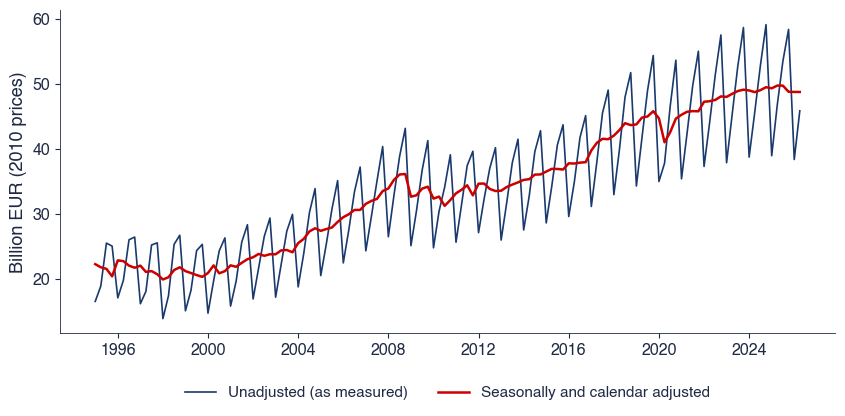

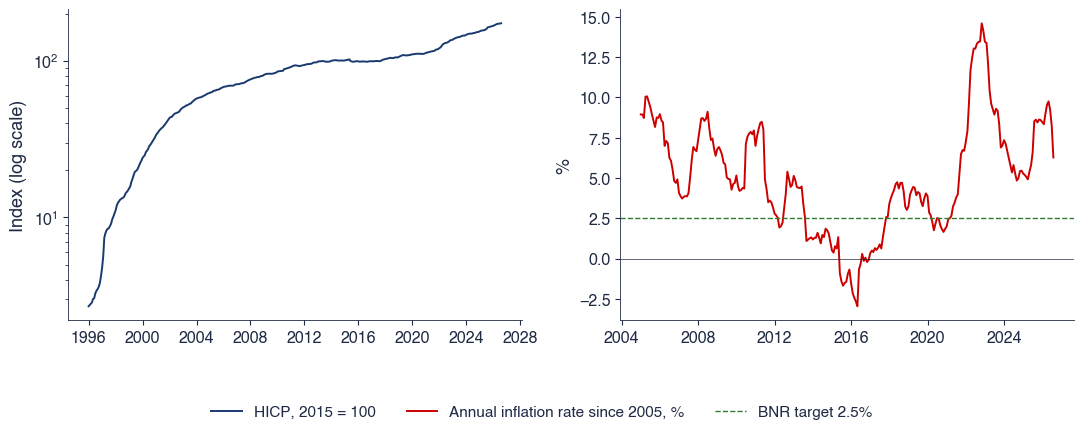

In [6]:
def fig_gdp(save=True):
    df = gdp_series()
    fig, ax = plt.subplots(figsize=(10, 4.2))
    ax.plot(df.index, df['nsa'] / 1000, color=st.MainBlue, lw=1.2, label='Unadjusted (as measured)')
    ax.plot(df.index, df['sca'] / 1000, color=st.IDAred, lw=1.8, label='Seasonally and calendar adjusted')
    ax.set_ylabel('Billion EUR (2010 prices)')
    st.legend_outside_bottom(ax, ncol=2, y=-0.12)
    st.check_no_grey(fig)
    if save:
        st.save_fig('tsa_ch0_gdp')
    return df


def fig_hicp(save=True):
    df = hicp_series()
    fig, axes = plt.subplots(1, 2, figsize=(11, 4.0))
    axes[0].plot(df.index, df['hicp'], color=st.MainBlue, lw=1.4, label='HICP, 2015 = 100')
    axes[0].set_ylabel('Index (log scale)')
    axes[0].set_yscale('log')
    inf = df['inflation'].loc[INFL_START:].dropna()
    axes[1].plot(inf.index, inf, color=st.IDAred, lw=1.4, label=f'Annual inflation rate since {INFL_START[:4]}, %')
    axes[1].axhline(2.5, color=st.Forest, ls='--', lw=1, label='BNR target 2.5%')
    axes[1].axhline(0, color=st.DarkText, lw=0.5)
    axes[1].set_ylabel('%')
    st.fig_legend_bottom(fig, ncol=3, y=0.0)
    fig.tight_layout(rect=(0, 0.07, 1, 1))
    st.check_no_grey(fig)
    if save:
        st.save_fig('tsa_ch0_hicp')
    return df


gdp = fig_gdp(save=False)
hicp = fig_hicp(save=False)
full = gdp['nsa'].groupby(gdp.index.year).sum()
print('annual GDP growth 2009 and 2020, %:', round(100 * (full[2009] / full[2008] - 1), 1), round(100 * (full[2020] / full[2019] - 1), 1))
print('latest annual inflation, %:', round(hicp['inflation'].iloc[-1], 1))

- EUR/RON (BNR reference rate): a stochastic trend, no seasonality.
- BET and S&P 500: value of 100 invested in January 2000, log scale.

EUR/RON first and last: 3.5986 5.2644
bet      7111.0
sp500     546.0
Name: 2026-09-18 00:00:00, dtype: float64


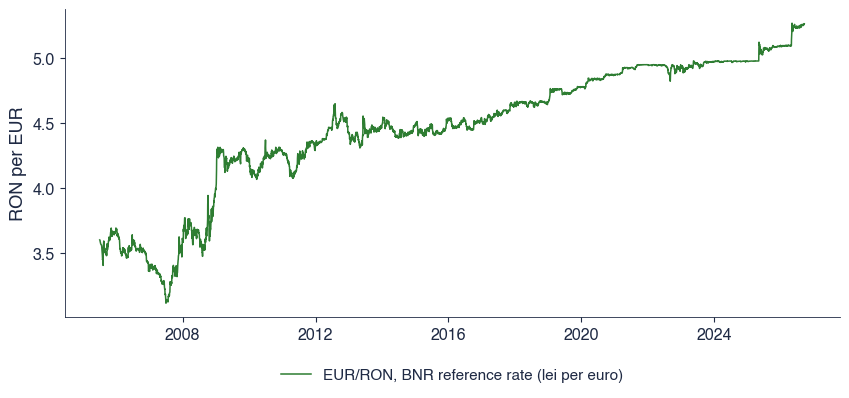

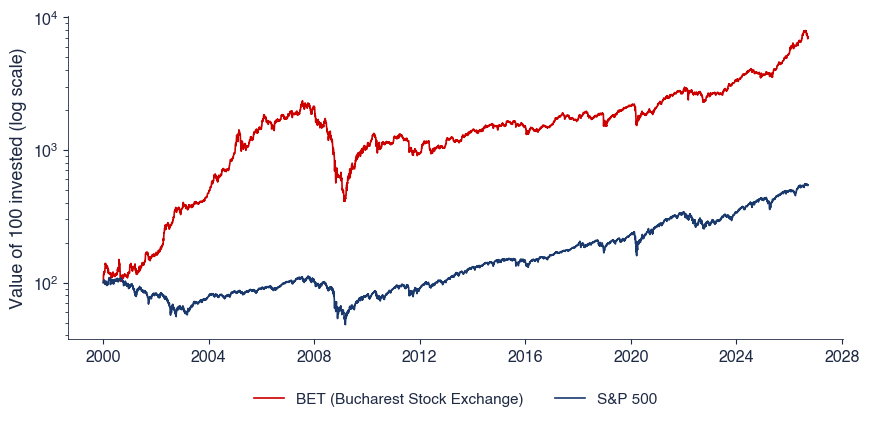

In [7]:
def fig_eurron(save=True):
    s = load_close('eurron')
    fig, ax = plt.subplots(figsize=(10, 4.0))
    ax.plot(s.index, s, color=st.Forest, lw=1.1, label='EUR/RON, BNR reference rate (lei per euro)')
    ax.set_ylabel('RON per EUR')
    st.legend_outside_bottom(ax, ncol=1, y=-0.12)
    st.check_no_grey(fig)
    if save:
        st.save_fig('tsa_ch0_eurron')
    return s


def fig_markets(save=True):
    px = pd.concat([load_close('bet', '2000-01-01'), load_close('sp500', '2000-01-01')], axis=1).ffill().dropna()
    idx = 100 * px / px.iloc[0]
    fig, ax = plt.subplots(figsize=(10, 4.2))
    ax.plot(idx.index, idx['bet'], color=st.COL['bet'], lw=1.2, label='BET (Bucharest Stock Exchange)')
    ax.plot(idx.index, idx['sp500'], color=st.COL['sp500'], lw=1.2, label='S&P 500')
    ax.set_yscale('log')
    ax.set_ylabel('Value of 100 invested (log scale)')
    st.legend_outside_bottom(ax, ncol=2, y=-0.12)
    st.check_no_grey(fig)
    if save:
        st.save_fig('tsa_ch0_markets')
    return idx


fx = fig_eurron(save=False)
idx = fig_markets(save=False)
print('EUR/RON first and last:', fx.iloc[0], fx.iloc[-1])
print(idx.iloc[-1].round(0))

- Electricity generation in Romania: a strong winter peak and a falling level.
- CO2 at Mauna Loa: a smooth trend and an additive yearly wave.

date
1     5.03
2     4.62
3     4.76
4     4.31
5     4.12
6     4.14
7     4.38
8     4.25
9     4.06
10    4.40
11    4.57
12    4.91
Name: elec, dtype: float64


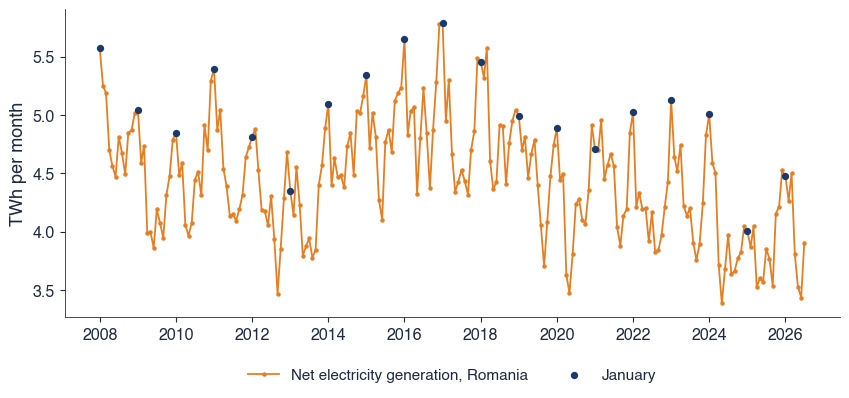

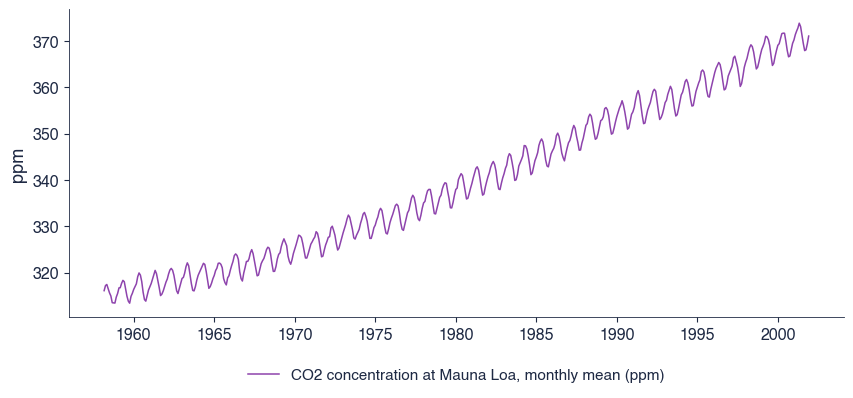

In [8]:
def fig_electricity(save=True):
    e = electricity_series()
    fig, ax = plt.subplots(figsize=(10, 4.0))
    ax.plot(e.index, e / 1000, color=st.Orange, lw=1.3, marker='o', ms=2.2, label='Net electricity generation, Romania')
    jan = e[e.index.month == 1]
    ax.scatter(jan.index, jan / 1000, color=st.MainBlue, s=18, zorder=3, label='January')
    ax.set_ylabel('TWh per month')
    st.legend_outside_bottom(ax, ncol=2, y=-0.12)
    st.check_no_grey(fig)
    if save:
        st.save_fig('tsa_ch0_electricity')
    return e


def fig_co2(save=True):
    c = co2_series()
    fig, ax = plt.subplots(figsize=(10, 4.0))
    ax.plot(c.index, c, color=st.Purple, lw=1.1, label='CO2 concentration at Mauna Loa, monthly mean (ppm)')
    ax.set_ylabel('ppm')
    st.legend_outside_bottom(ax, ncol=1, y=-0.12)
    st.check_no_grey(fig)
    if save:
        st.save_fig('tsa_ch0_co2')
    return c


el = fig_electricity(save=False)
co2 = fig_co2(save=False)
print((el.groupby(el.index.month).mean() / 1000).round(2))

## 2. Slutsky's experiment

- A moving sum of 10 independent shocks: $y_t = \varepsilon_t + \dots + \varepsilon_{t-9}$.
- Waves appear although no cycle was put in.

upward zero crossings: 16


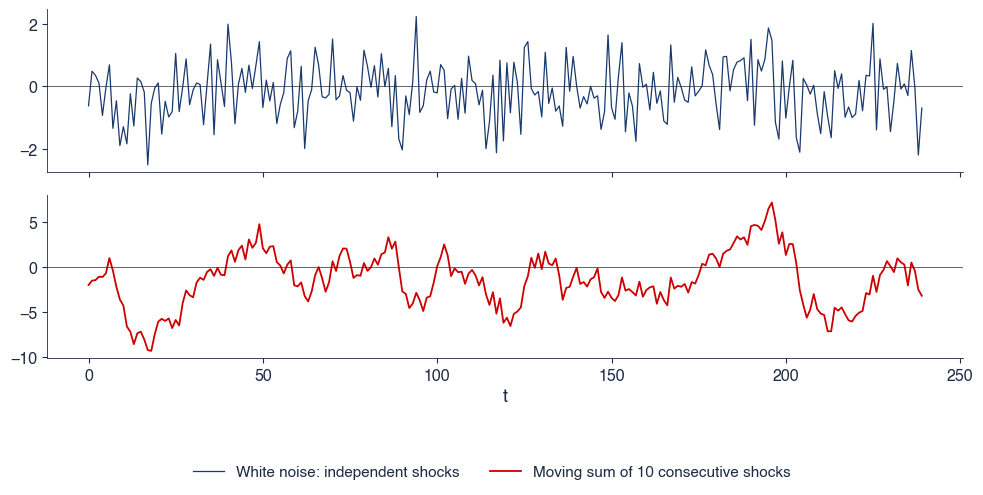

In [9]:
def fig_slutsky(n=240, k=10, seed=7, save=True):
    """Slutsky (1937): a moving sum of k independent shocks produces smooth, cycle-like waves."""
    rng = np.random.default_rng(seed)
    eps = rng.standard_normal(n + k - 1)
    ma = np.convolve(eps, np.ones(k), mode='valid')            # y_t = eps_t + ... + eps_{t-k+1}
    fig, axes = plt.subplots(2, 1, figsize=(10, 4.6), sharex=True)
    axes[0].plot(np.arange(n), eps[k - 1:], color=st.MainBlue, lw=0.9, label='White noise: independent shocks')
    axes[1].plot(np.arange(n), ma, color=st.IDAred, lw=1.3, label=f'Moving sum of {k} consecutive shocks')
    for a in axes:
        a.axhline(0, color=st.DarkText, lw=0.5)
    axes[1].set_xlabel('t')
    st.fig_legend_bottom(fig, ncol=2, y=0.0)
    fig.tight_layout(rect=(0, 0.06, 1, 1))
    st.check_no_grey(fig)
    if save:
        st.save_fig('tsa_ch0_slutsky')
    # number of up-crossings of zero: about one wave every 2k periods
    up = int(((ma[:-1] < 0) & (ma[1:] >= 0)).sum())
    return eps, ma, up


eps, ma, up = fig_slutsky(save=False)
print('upward zero crossings:', up)

## 3. Decomposition

- Classical multiplicative decomposition of GDP: $2 \times 4$ centred moving average, seasonal factors, remainder.
- STL (robust, period 12) of the CO2 series: the seasonal pattern may change slowly.

seasonal factors: {1: 0.762, 2: 0.918, 3: 1.113, 4: 1.207}


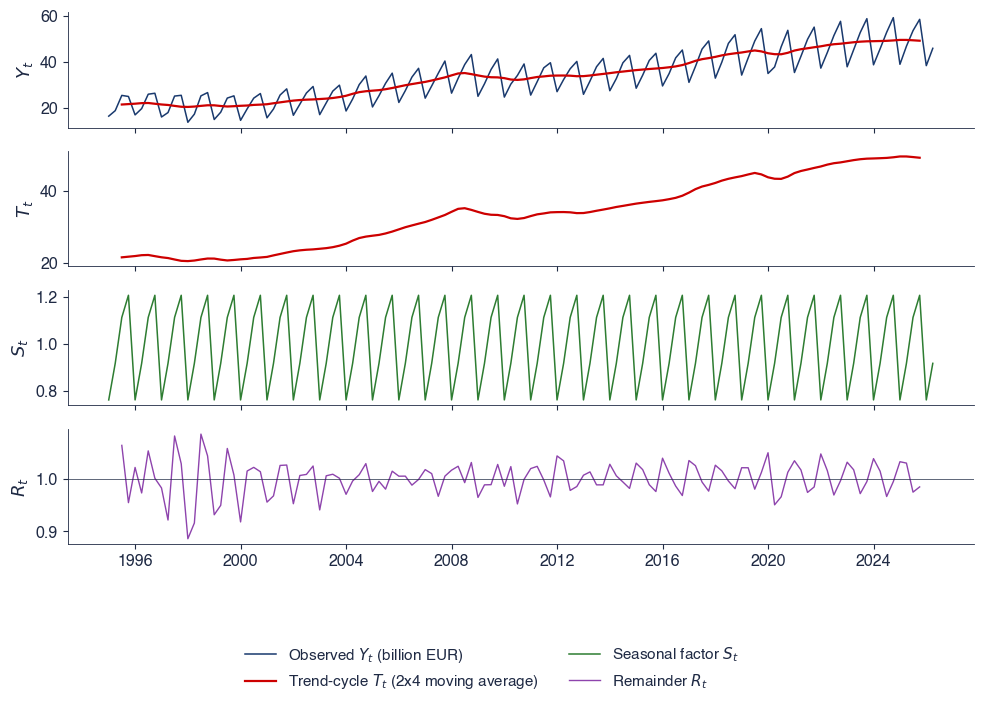

In [10]:
def classical_decomposition(y, m, model='multiplicative'):
    """Classical decomposition: centred moving average of order m (2 x m for even m), seasonal indices as the
    average detrended value of each season (normalised), remainder = what is left."""
    if m % 2 == 0:
        w = np.r_[0.5, np.ones(m - 1), 0.5] / m                # 2 x m centred moving average
    else:
        w = np.ones(m) / m
    trend = pd.Series(np.convolve(y.values, w, mode='same'), index=y.index)
    half = len(w) // 2
    trend.iloc[:half] = np.nan
    trend.iloc[-half:] = np.nan
    detr = y / trend if model == 'multiplicative' else y - trend
    pos = np.arange(len(y)) % m
    raw = pd.Series(detr.values).groupby(pos).mean()
    idx = raw / raw.mean() if model == 'multiplicative' else raw - raw.mean()
    seasonal = pd.Series(idx.values[pos], index=y.index)
    rem = y / (trend * seasonal) if model == 'multiplicative' else y - trend - seasonal
    season_of = {p: y.index[p] for p in range(m)}
    return trend, seasonal, rem, idx, season_of


def fig_components(save=True):
    y = gdp_series()['nsa'] / 1000
    trend, seas, rem, idx, _ = classical_decomposition(y, 4, 'multiplicative')
    fig, axes = plt.subplots(4, 1, figsize=(10, 6.4), sharex=True)
    axes[0].plot(y.index, y, color=st.MainBlue, lw=1.1, label='Observed $Y_t$ (billion EUR)')
    axes[0].plot(trend.index, trend, color=st.IDAred, lw=1.6, label='Trend-cycle $T_t$ (2x4 moving average)')
    axes[1].plot(trend.index, trend, color=st.IDAred, lw=1.6)
    axes[1].set_ylabel('$T_t$')
    axes[2].plot(seas.index, seas, color=st.Forest, lw=1.1, label='Seasonal factor $S_t$')
    axes[2].set_ylabel('$S_t$')
    axes[3].plot(rem.index, rem, color=st.Purple, lw=1.0, label='Remainder $R_t$')
    axes[3].axhline(1, color=st.DarkText, lw=0.5)
    axes[3].set_ylabel('$R_t$')
    axes[0].set_ylabel('$Y_t$')
    st.fig_legend_bottom(fig, ncol=2, y=0.0)
    fig.tight_layout(rect=(0, 0.07, 1, 1))
    st.check_no_grey(fig)
    if save:
        st.save_fig('tsa_ch0_components')
    q = {int(y.index[p].quarter): float(idx[p]) for p in range(4)}
    return y, trend, seas, rem, q


y, trend, seas, rem, q = fig_components(save=False)
print('seasonal factors:', {k: round(v, 3) for k, v in q.items()})

remainder sd (ppm):

 0.255


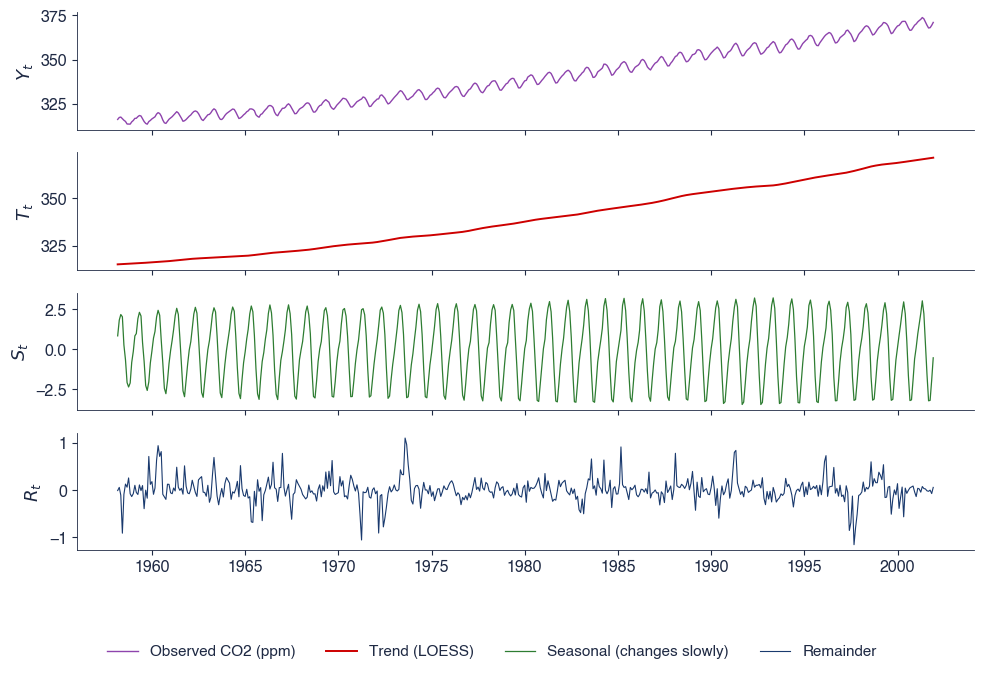

In [11]:
def fig_stl(save=True):
    from statsmodels.tsa.seasonal import STL
    c = co2_series()
    res = STL(c, period=12, robust=True).fit()
    fig, axes = plt.subplots(4, 1, figsize=(10, 6.4), sharex=True)
    axes[0].plot(c.index, c, color=st.Purple, lw=1.0, label='Observed CO2 (ppm)')
    axes[1].plot(c.index, res.trend, color=st.IDAred, lw=1.4, label='Trend (LOESS)')
    axes[2].plot(c.index, res.seasonal, color=st.Forest, lw=0.9, label='Seasonal (changes slowly)')
    axes[3].plot(c.index, res.resid, color=st.MainBlue, lw=0.8, label='Remainder')
    for a, lab in zip(axes, ['$Y_t$', '$T_t$', '$S_t$', '$R_t$']):
        a.set_ylabel(lab)
    st.fig_legend_bottom(fig, ncol=4, y=0.0)
    fig.tight_layout(rect=(0, 0.06, 1, 1))
    st.check_no_grey(fig)
    if save:
        st.save_fig('tsa_ch0_stl')
    return c, res


c, res = fig_stl(save=False)
print('remainder sd (ppm):', round(res.resid.std(), 3))

## 4. Transformations and the ACF

- Daily log returns of the BET: $r_t = 100(\ln P_t - \ln P_{t-1})$.
- Sample ACF $r_k = c_k / c_0$ with the band $\pm 1.96/\sqrt{T}$: slow decay (trend), peaks at 12 (season), almost no memory (returns).

CO2 level (monthly): r1 = 0.993, r12 = 0.935, band = 0.085
Electricity generation (monthly): r1 = 0.754, r12 = 0.589, band = 0.131
BET daily log returns: r1 = 0.109, r12 = 0.002, band = 0.024


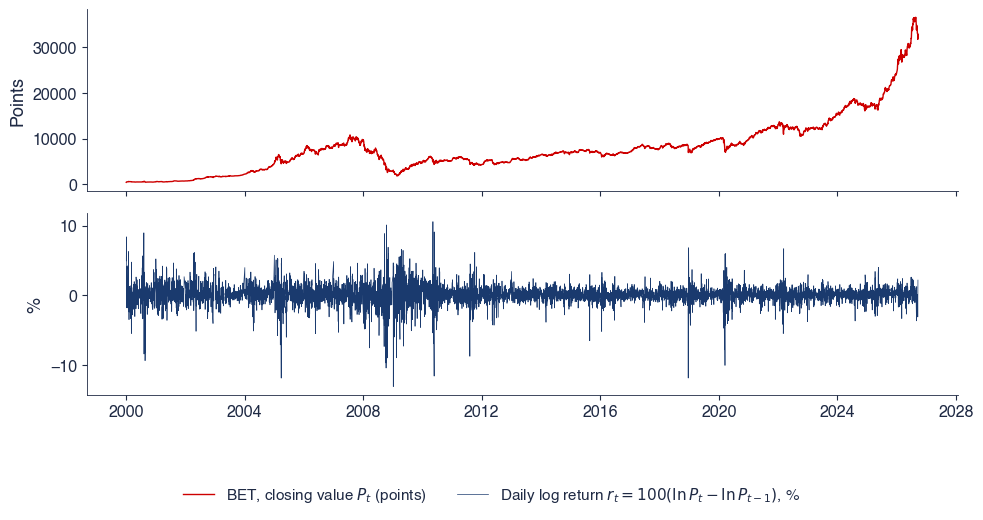

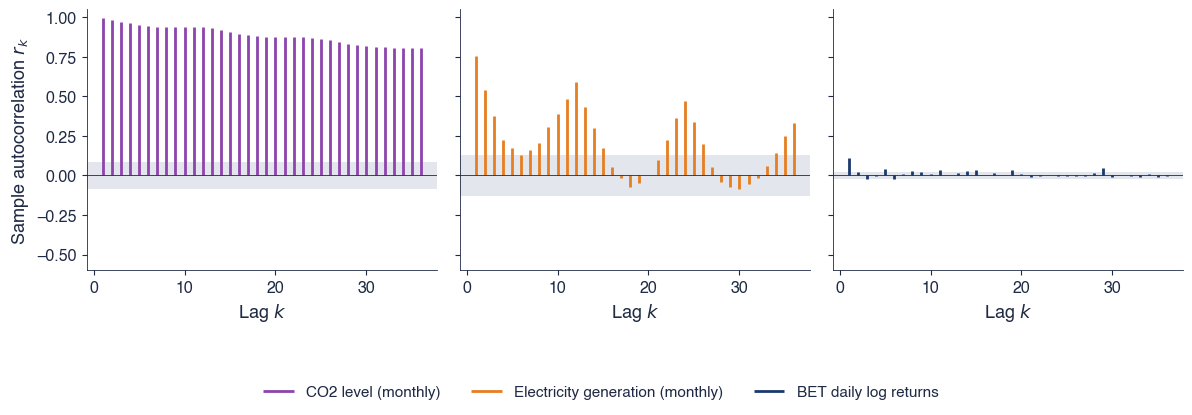

In [12]:
def fig_returns(save=True):
    p = load_close('bet', '2000-01-01')
    r = log_returns('bet', '2000-01-01')
    fig, axes = plt.subplots(2, 1, figsize=(10, 4.8), sharex=True)
    axes[0].plot(p.index, p, color=st.COL['bet'], lw=1.0, label='BET, closing value $P_t$ (points)')
    axes[1].plot(r.index, r, color=st.MainBlue, lw=0.5, label='Daily log return $r_t = 100(\\ln P_t - \\ln P_{t-1})$, %')
    axes[0].set_ylabel('Points')
    axes[1].set_ylabel('%')
    st.fig_legend_bottom(fig, ncol=2, y=0.0)
    fig.tight_layout(rect=(0, 0.07, 1, 1))
    st.check_no_grey(fig)
    if save:
        st.save_fig('tsa_ch0_returns')
    return p, r


def sample_acf(x, nlags):
    """Sample autocorrelations r_1..r_nlags: sum of (x_t - mean)(x_{t-k} - mean) over T, divided by the variance."""
    x = np.asarray(x, dtype=float)
    x = x - x.mean()
    c0 = np.sum(x * x) / len(x)
    return np.array([np.sum(x[k:] * x[:-k]) / len(x) / c0 for k in range(1, nlags + 1)])


def fig_acf(save=True):
    c = co2_series()
    e = electricity_series()
    r = log_returns('bet', '2000-01-01')
    panels = [('CO2 level (monthly)', c, 36, st.Purple), ('Electricity generation (monthly)', e, 36, st.Orange),
              ('BET daily log returns', r, 36, st.MainBlue)]
    fig, axes = plt.subplots(1, 3, figsize=(12, 3.8), sharey=True)
    out = {}
    for ax, (lab, x, L, col) in zip(axes, panels):
        a = sample_acf(x, L)
        band = 1.96 / np.sqrt(len(x))
        ax.vlines(np.arange(1, L + 1), 0, a, color=col, lw=2, label=lab)
        ax.axhline(0, color=st.DarkText, lw=0.6)
        ax.axhspan(-band, band, color=st.MainBlue, alpha=0.12, lw=0)
        ax.set_xlabel('Lag $k$')
        ax.set_ylim(-0.6, 1.05)
        out[lab] = (a, band, len(x))
    axes[0].set_ylabel('Sample autocorrelation $r_k$')
    st.fig_legend_bottom(fig, ncol=3, y=0.0)
    fig.tight_layout(rect=(0, 0.08, 1, 1))
    st.check_no_grey(fig)
    if save:
        st.save_fig('tsa_ch0_acf')
    return out


p, r = fig_returns(save=False)
out = fig_acf(save=False)
for k, (a, band, n) in out.items():
    print(f'{k}: r1 = {a[0]:.3f}, r12 = {a[11]:.3f}, band = {band:.3f}')

## 5. Simple exponential smoothing

- $\ell_t = \alpha y_t + (1-\alpha)\ell_{t-1}$; the one-step forecast is $\ell_{t-1}$.
- Worked example of the slides: $y = 10, 12, 11, 13$, $\alpha = 0.5$, $\ell_0 = 10$.

[10. 11. 11. 12.]


estimated alpha for EUR/RON: 1.0


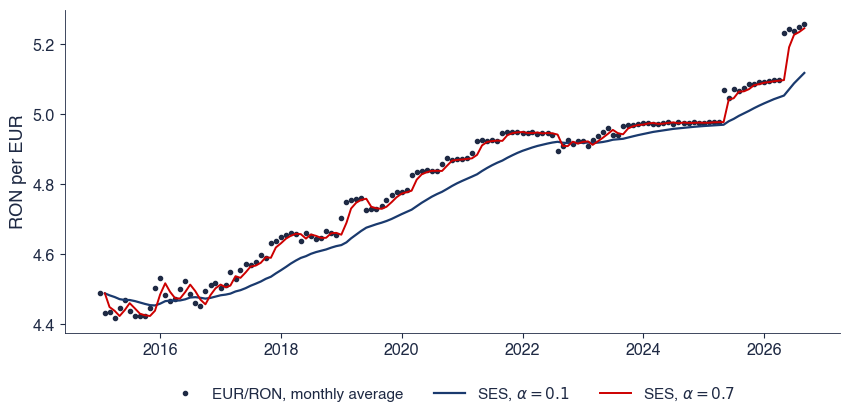

In [13]:
def ses_path(y, alpha, level0=None):
    """Simple exponential smoothing: level l_t = alpha y_t + (1 - alpha) l_{t-1}; the forecast of y_{t+1} is l_t."""
    lev = np.empty(len(y))
    prev = y.iloc[0] if level0 is None else level0
    for i, v in enumerate(y.values):
        prev = alpha * v + (1 - alpha) * prev
        lev[i] = prev
    return pd.Series(lev, index=y.index)


def eurron_monthly(start='2015-01-01'):
    s = load_close('eurron', start)
    return s.resample('MS').mean().rename('eurron')


def fig_ses(save=True):
    from statsmodels.tsa.holtwinters import SimpleExpSmoothing
    y = eurron_monthly()
    fit = SimpleExpSmoothing(y, initialization_method='estimated').fit()
    fig, ax = plt.subplots(figsize=(10, 4.2))
    ax.plot(y.index, y, color=st.DarkText, lw=0.0, marker='o', ms=3, label='EUR/RON, monthly average')
    ax.plot(y.index, ses_path(y, 0.1).shift(1), color=st.MainBlue, lw=1.6, label='SES, $\\alpha = 0.1$')
    ax.plot(y.index, ses_path(y, 0.7).shift(1), color=st.IDAred, lw=1.4, label='SES, $\\alpha = 0.7$')
    ax.set_ylabel('RON per EUR')
    st.legend_outside_bottom(ax, ncol=3, y=-0.12)
    st.check_no_grey(fig)
    if save:
        st.save_fig('tsa_ch0_ses')
    return y, float(fit.params['smoothing_level'])


print(ses_path(pd.Series([10.0, 12.0, 11.0, 13.0]), 0.5, level0=10).values)   # levels 10, 11, 11, 12
y, alpha = fig_ses(save=False)
print('estimated alpha for EUR/RON:', round(alpha, 3))

## 6. Forecasts and their evaluation

- Training set and test set split by time; naive, seasonal naive, SES and Holt-Winters.
- MAE, RMSE, MAPE and MASE (scaled by the in-sample MAE of the seasonal naive method).

,MAE,RMSE,MAPE,MASE
Naive,0.282,0.327,7.302,0.824
Seasonal naive,0.285,0.378,7.246,0.833
SES,0.276,0.323,7.120,0.807
Holt-Winters,0.173,0.209,4.464,0.505


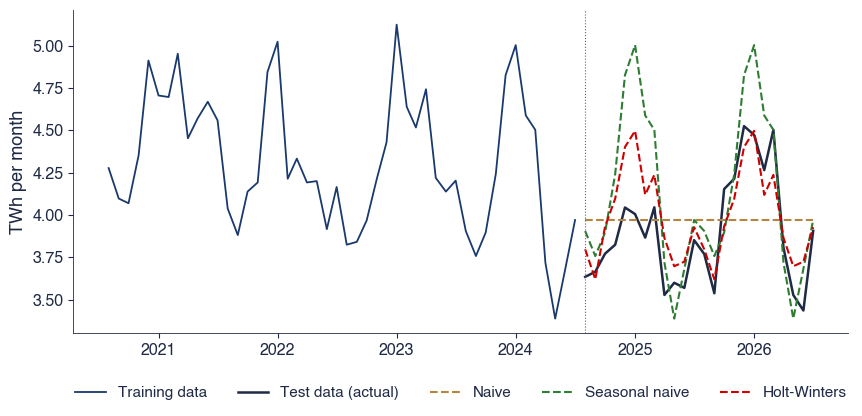

In [14]:
def method_forecasts(y, m, h):
    """Forecasts of the last h values from the first len(y) - h: naive, seasonal naive, SES and Holt-Winters
    (additive damped trend, multiplicative seasonality), all fitted on the training set only."""
    from statsmodels.tsa.holtwinters import ExponentialSmoothing, SimpleExpSmoothing
    train, test = y.iloc[:-h], y.iloc[-h:]
    f = {}
    f['Naive'] = pd.Series(train.iloc[-1], index=test.index)
    f['Seasonal naive'] = pd.Series([train.iloc[len(train) - m + (i % m)] for i in range(h)], index=test.index)
    f['SES'] = pd.Series(SimpleExpSmoothing(train, initialization_method='estimated').fit().forecast(h).values,
                         index=test.index)
    hw = ExponentialSmoothing(train, trend='add', damped_trend=True, seasonal='mul', seasonal_periods=m,
                              initialization_method='estimated').fit()
    f['Holt-Winters'] = pd.Series(hw.forecast(h).values, index=test.index)
    return train, test, f


def accuracy(train, test, fc, m):
    """MAE, RMSE, MAPE (%) and MASE; the MASE scale is the in-sample MAE of the seasonal naive method (lag m)."""
    e = test - fc
    scale = np.mean(np.abs(train.values[m:] - train.values[:-m]))
    return {'MAE': float(np.mean(np.abs(e))), 'RMSE': float(np.sqrt(np.mean(e ** 2))),
            'MAPE': float(100 * np.mean(np.abs(e / test))), 'MASE': float(np.mean(np.abs(e)) / scale)}


def fig_forecast(save=True):
    y = electricity_series() / 1000
    train, test, f = method_forecasts(y, 12, TEST_H['elec'])
    fig, ax = plt.subplots(figsize=(10, 4.2))
    tail = train.iloc[-48:]
    ax.plot(tail.index, tail, color=st.MainBlue, lw=1.3, label='Training data')
    ax.plot(test.index, test, color=st.DarkText, lw=1.8, label='Test data (actual)')
    cols = {'Naive': st.Amber, 'Seasonal naive': st.Forest, 'Holt-Winters': st.IDAred}
    for k, c in cols.items():
        ax.plot(f[k].index, f[k], color=c, lw=1.5, ls='--', label=k)
    ax.axvline(test.index[0], color=st.Purple, lw=0.8, ls=':')
    ax.set_ylabel('TWh per month')
    st.legend_outside_bottom(ax, ncol=5, y=-0.12)
    st.check_no_grey(fig)
    if save:
        st.save_fig('tsa_ch0_forecast')
    acc = {k: accuracy(train, test, v, 12) for k, v in f.items()}
    return train, test, f, acc


train, test, f, acc = fig_forecast(save=False)
pd.DataFrame(acc).T.round(3)

- A small M-competition: the four methods on four seasonal series.

method,Holt-Winters,Naive,SES,Seasonal naive
series,,,,
gdp,0.65,4.62,4.39,0.29
hicp,0.68,2.24,2.24,2.80
elec,0.51,0.82,0.81,0.83
co2,0.26,1.86,1.86,1.45


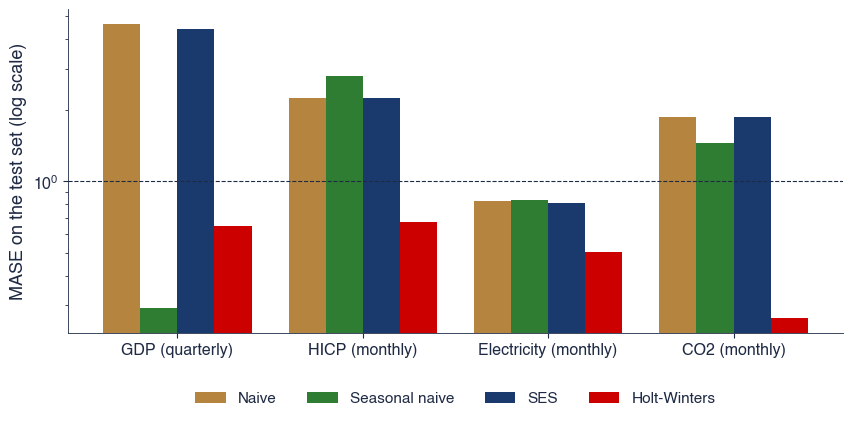

In [15]:
def benchmark_data():
    return {'gdp': gdp_series()['nsa'] / 1000, 'hicp': hicp_series()['hicp'],
            'elec': electricity_series() / 1000, 'co2': co2_series()}


def fig_benchmarks(save=True):
    data = benchmark_data()
    rows = []
    for k, y in data.items():
        train, test, f = method_forecasts(y, SEASON[k], TEST_H[k])
        for meth, fc in f.items():
            a = accuracy(train, test, fc, SEASON[k])
            rows.append(dict(series=k, method=meth, **a))
    tab = pd.DataFrame(rows)
    piv = tab.pivot(index='series', columns='method', values='MASE').loc[list(data)]
    meths = ['Naive', 'Seasonal naive', 'SES', 'Holt-Winters']
    cols = [st.Amber, st.Forest, st.MainBlue, st.IDAred]
    fig, ax = plt.subplots(figsize=(10, 4.2))
    x = np.arange(len(piv))
    for i, (mth, c) in enumerate(zip(meths, cols)):
        ax.bar(x + (i - 1.5) * 0.2, piv[mth], width=0.2, color=c, label=mth)
    ax.axhline(1, color=st.DarkText, lw=0.8, ls='--')
    ax.set_xticks(x)
    ax.set_xticklabels([SERIES_LABEL[k] for k in piv.index])
    ax.set_yscale('log')
    ax.set_ylabel('MASE on the test set (log scale)')
    st.legend_outside_bottom(ax, ncol=4, y=-0.14)
    st.check_no_grey(fig)
    if save:
        st.save_fig('tsa_ch0_benchmarks')
    return tab, piv


tab, piv = fig_benchmarks(save=False)
piv.round(2)